# Task 6 — Outlier Detection & Treatment (Z-score and IQR)

We use the real **California Housing** dataset (1990 census, 20,640 block
groups) and detect/treat outliers in its numeric features using both the
**z-score** method and the **IQR** method.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid")

housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.shape)
print(df.isnull().sum())
df.describe().T

(20640, 9)
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Z-score method

Flag any value with $|z| = \left|\frac{x - \mu}{\sigma}\right| > 3$ as an outlier.

In [2]:
numeric_cols = df.columns.tolist()
z_scores = df[numeric_cols].apply(stats.zscore)
z_outliers = (z_scores.abs() > 3)

print("outlier counts per column (z-score, |z|>3):")
print(z_outliers.sum().sort_values(ascending=False))
print("\nrows with >=1 z-score outlier:", (z_outliers.any(axis=1)).sum())

outlier counts per column (z-score, |z|>3):
MedInc         345
Population     342
AveBedrms      145
AveRooms       133
AveOccup         8
HouseAge         0
Latitude         0
Longitude        0
MedHouseVal      0
dtype: int64

rows with >=1 z-score outlier: 846


## IQR method

Flag values outside $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$.

In [3]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = (df[numeric_cols].lt(lower_bound)) | (df[numeric_cols].gt(upper_bound))

print("outlier counts per column (IQR):")
print(iqr_outliers.sum().sort_values(ascending=False))
print("\nrows with >=1 IQR outlier:", (iqr_outliers.any(axis=1)).sum())

outlier counts per column (IQR):
AveBedrms      1424
Population     1196
MedHouseVal    1071
AveOccup        711
MedInc          681
AveRooms        511
HouseAge          0
Latitude          0
Longitude         0
dtype: int64

rows with >=1 IQR outlier: 4328


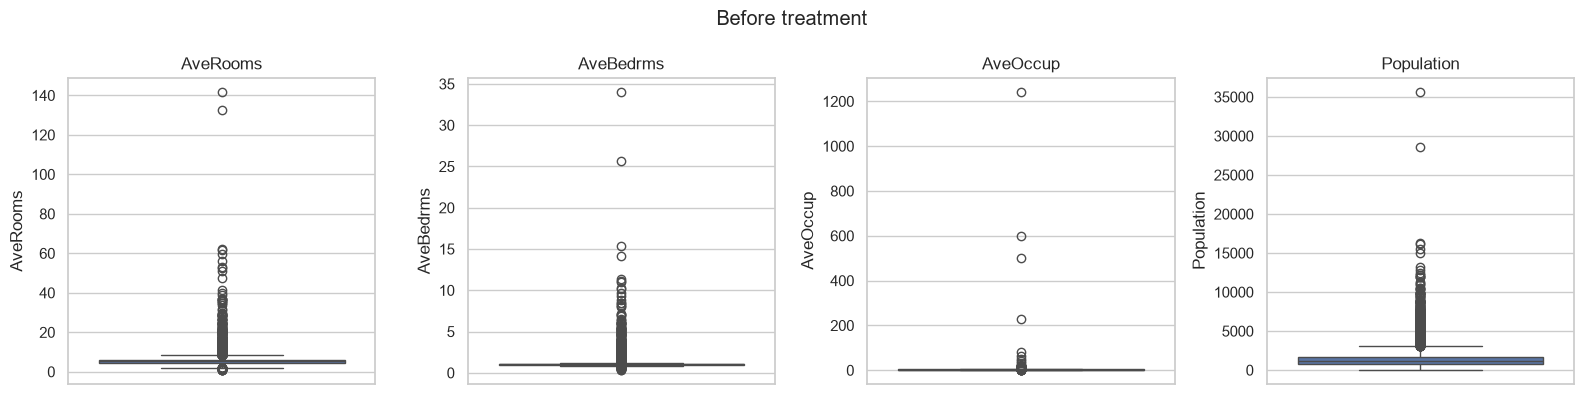

In [4]:
plot_cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(16, 4))
for ax, col in zip(axes, plot_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
fig.suptitle("Before treatment")
plt.tight_layout()
plt.show()

## Treatment

Two common strategies, demonstrated on the IQR-flagged rows/values:

1. **Removal** — drop rows flagged as outliers on any column.
2. **Capping (winsorizing)** — clip values to the IQR bounds instead of
   dropping the row (preserves sample size, standard when outliers are
   plausible-but-extreme rather than data-entry errors).

In [5]:
df_removed = df[~iqr_outliers.any(axis=1)].reset_index(drop=True)
print(f"rows before: {len(df)}, after removal: {len(df_removed)}")
df_removed[plot_cols].describe().T[["mean", "std", "min", "max"]]

rows before: 20640, after removal: 16312


,mean,std,min,max
AveRooms,5.156007,1.043588,2.032738,8.452915
AveBedrms,1.047226,0.066569,0.866013,1.239521
AveOccup,2.865163,0.624931,1.161290,4.560748
Population,1271.783227,627.384658,5.000000,3132.000000


In [6]:
df_capped = df.copy()
for col in numeric_cols:
    df_capped[col] = df_capped[col].clip(lower=lower_bound[col], upper=upper_bound[col])

comparison = pd.concat(
    {"before": df[plot_cols].describe().T[["mean", "std", "min", "max"]],
     "after_capping": df_capped[plot_cols].describe().T[["mean", "std", "min", "max"]]},
    axis=1,
)
comparison

before                                      after_capping  \
                   mean          std       min           max          mean   
AveRooms       5.429000     2.474173  0.846154    141.909091      5.304740   
AveBedrms      1.096675     0.473911  0.333333     34.066667      1.057958   
AveOccup       3.070655    10.386050  0.692308   1243.333333      2.899647   
Population  1425.476744  1132.462122  3.000000  35682.000000   1336.959012   

                                               
                   std       min          max  
AveRooms      1.246177  2.023219     8.469878  
AveBedrms     0.080448  0.865909     1.239697  
AveOccup      0.691142  1.150961     4.561041  
Population  765.550830  3.000000  3132.000000

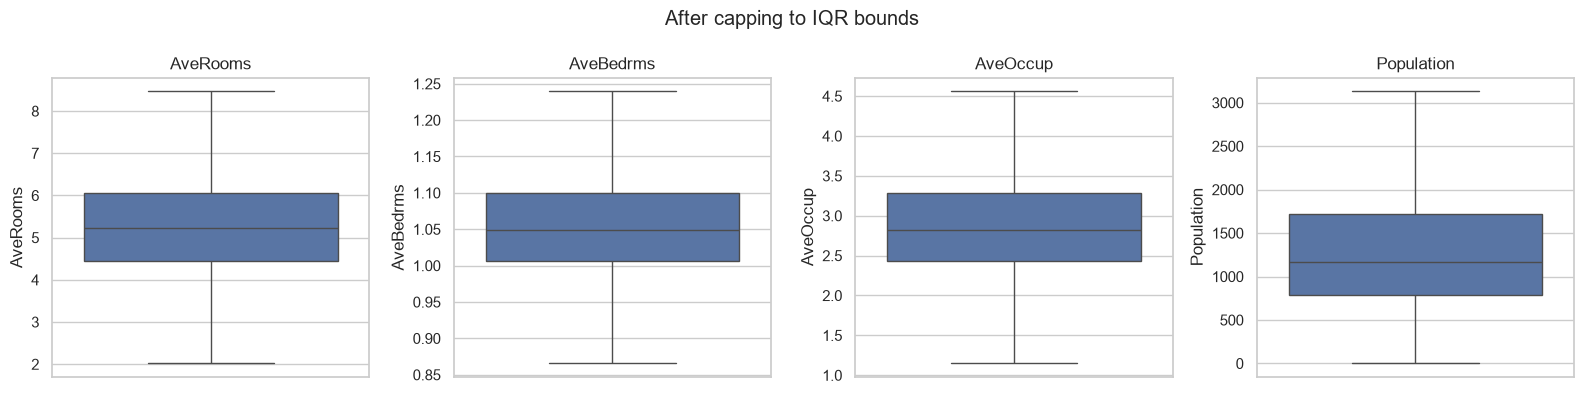

In [7]:
fig, axes = plt.subplots(1, len(plot_cols), figsize=(16, 4))
for ax, col in zip(axes, plot_cols):
    sns.boxplot(y=df_capped[col], ax=ax)
    ax.set_title(col)
fig.suptitle("After capping to IQR bounds")
plt.tight_layout()
plt.show()

## Conclusion

Both methods flag largely overlapping but not identical rows (z-score assumes
approximate normality, which several of these skewed housing features violate,
so IQR is the more robust choice here). Capping preserves all 20,640 rows
while visibly tightening the spread of `AveRooms`, `AveBedrms`, and
`AveOccup`; removal is simpler but discards ~5% of rows.